# Обработка для обучения

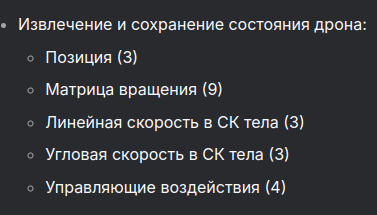

In [2]:
import pickle
import pandas as pd
import numpy as np

In [3]:
with open('output/output.pkl', 'rb') as f:
    dr = pd.DataFrame(pickle.load(f))

In [4]:
dr.head(1)   

,time,observation,q,qd,q_des,qd_des,Kp,Kd,action
0,0.0,"[0.9994169473648071, 0.013401591219007969, -0....","[-0.03313338756561279, 0.8366715908050537, -1....","[0.0, -0.0, -0.05625000223517418, 0.0, 0.0, 0....","(-1.0142389150757936e-08, 0.9191587567329407, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(70.0, 70.0, 80.0, 70.0, 70.0, 80.0, 70.0, 70....","(5.0, 5.0, 7.0, 5.0, 5.0, 7.0, 5.0, 5.0, 7.0, ...","[-0.06077812984585762, -0.02693609520792961, 0..."


In [5]:
#добавляем воздействия согласно формуле из статьи
dr['torque'] = dr.apply(lambda row: np.array(row['Kp']*(row['q_des']-row['q']) + row['Kd']*row['qd']), axis=1)
dr.head(1)

,time,observation,q,qd,q_des,qd_des,Kp,Kd,action,torque
0,0.0,"[0.9994169473648071, 0.013401591219007969, -0....","[-0.03313338756561279, 0.8366715908050537, -1....","[0.0, -0.0, -0.05625000223517418, 0.0, 0.0, 0....","(-1.0142389150757936e-08, 0.9191587567329407, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(70.0, 70.0, 80.0, 70.0, 70.0, 80.0, 70.0, 70....","(5.0, 5.0, 7.0, 5.0, 5.0, 7.0, 5.0, 5.0, 7.0, ...","[-0.06077812984585762, -0.02693609520792961, 0...","[2.319336419625655, 5.774101614952087, 13.0534..."


In [6]:
#добавляем кватернионы из наблюдений
dr['quaternion'] = dr.apply(lambda row: np.array(row['observation'][0:4]), axis=1)
dr.head(1)

,time,observation,q,qd,q_des,qd_des,Kp,Kd,action,torque,quaternion
0,0.0,"[0.9994169473648071, 0.013401591219007969, -0....","[-0.03313338756561279, 0.8366715908050537, -1....","[0.0, -0.0, -0.05625000223517418, 0.0, 0.0, 0....","(-1.0142389150757936e-08, 0.9191587567329407, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(70.0, 70.0, 80.0, 70.0, 70.0, 80.0, 70.0, 70....","(5.0, 5.0, 7.0, 5.0, 5.0, 7.0, 5.0, 5.0, 7.0, ...","[-0.06077812984585762, -0.02693609520792961, 0...","[2.319336419625655, 5.774101614952087, 13.0534...","[0.9994169473648071, 0.013401591219007969, -0...."


In [7]:
#add base lineary velosity
dr['base_vel_lin'] = dr.apply(lambda row: np.array(row['observation'][16:19]), axis=1)
dr.head(1)

,time,observation,q,qd,q_des,qd_des,Kp,Kd,action,torque,quaternion,base_vel_lin
0,0.0,"[0.9994169473648071, 0.013401591219007969, -0....","[-0.03313338756561279, 0.8366715908050537, -1....","[0.0, -0.0, -0.05625000223517418, 0.0, 0.0, 0....","(-1.0142389150757936e-08, 0.9191587567329407, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(70.0, 70.0, 80.0, 70.0, 70.0, 80.0, 70.0, 70....","(5.0, 5.0, 7.0, 5.0, 5.0, 7.0, 5.0, 5.0, 7.0, ...","[-0.06077812984585762, -0.02693609520792961, 0...","[2.319336419625655, 5.774101614952087, 13.0534...","[0.9994169473648071, 0.013401591219007969, -0....","[0.01994507946074009, 0.03432182967662811, -0...."


In [8]:
#add base lineary velosity
dr['base_vel_ang'] = dr.apply(lambda row: np.array(row['observation'][19:22]), axis=1)
dr.head(1)

,time,observation,q,qd,q_des,qd_des,Kp,Kd,action,torque,quaternion,base_vel_lin,base_vel_ang
0,0.0,"[0.9994169473648071, 0.013401591219007969, -0....","[-0.03313338756561279, 0.8366715908050537, -1....","[0.0, -0.0, -0.05625000223517418, 0.0, 0.0, 0....","(-1.0142389150757936e-08, 0.9191587567329407, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(70.0, 70.0, 80.0, 70.0, 70.0, 80.0, 70.0, 70....","(5.0, 5.0, 7.0, 5.0, 5.0, 7.0, 5.0, 5.0, 7.0, ...","[-0.06077812984585762, -0.02693609520792961, 0...","[2.319336419625655, 5.774101614952087, 13.0534...","[0.9994169473648071, 0.013401591219007969, -0....","[0.01994507946074009, 0.03432182967662811, -0....","[-0.0015413538785651326, 0.004035827703773975,..."


In [9]:
from scipy.integrate import cumulative_trapezoid

dr['base_pos'] = cumulative_trapezoid(dr['base_vel_lin'], dr['time'], initial=0)


In [13]:
dr['base_pos'][1]

array([ 0.00426359,  0.0073372 , -0.15170878])

In [21]:
from scipy.spatial.transform import Rotation
# Применяем Rotation.from_quat к каждому кватерниону
dr['R_mat'] = dr['quaternion'].apply(
    lambda q: Rotation.from_quat(q).as_matrix()
)

(3, 3)